# Macroevolutionary Modeling of Continuous Trait Evolution

*Converted from R to Python (numpy / pandas / matplotlib)*

Author: Jay Heejae Jang

**Note on packages:** the original R analysis relies on specialized phylogenetics
packages (`phytools`, `TreeSim`, `diverge`) that have no drop-in Python
equivalent. Rather than depend on a fragile chain of niche libraries, this
notebook reimplements the underlying stochastic processes directly
(Brownian motion random walks, a birth–death branching process, and an
Ornstein–Uhlenbeck process) using plain `numpy`. The statistical behavior is
equivalent; exact simulated values will differ from the R version since the
two languages use different random number generators, even with a matching
seed.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 5)


## Brownian motion under two variance regimes

In a Brownian motion (BM) model, the variance parameter (sigma^2) represents
the evolutionary rate at which trait variance accumulates through time. The
simulation below tracks cumulative BM random walks from an ancestral
mysticete body size (4 m) under two distinct variance regimes over 100 time
steps.


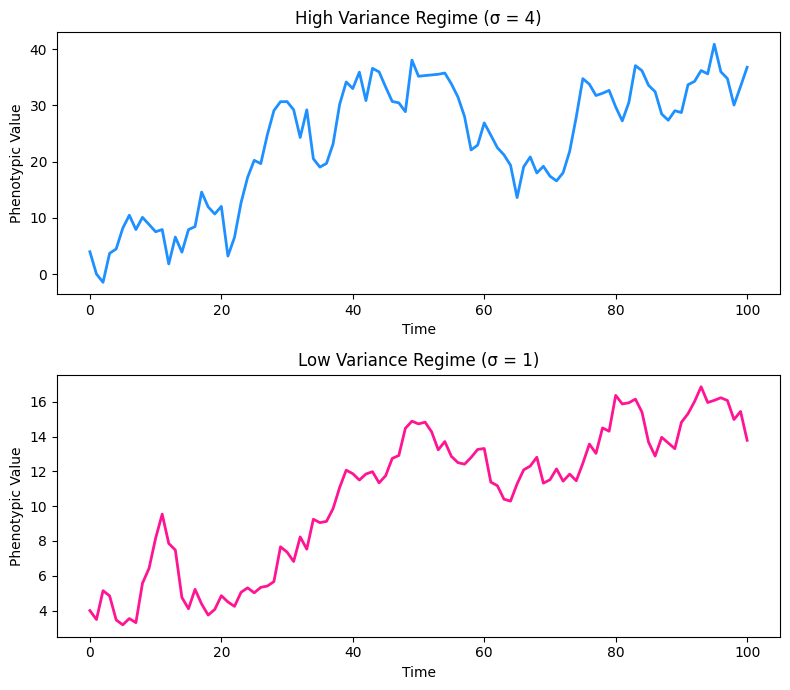

In [2]:
rng = np.random.default_rng(123)

n_step = 100
start_point = 4.0

normal1 = rng.normal(loc=0, scale=4, size=n_step)
normal2 = rng.normal(loc=0, scale=1, size=n_step)

random_walk1 = np.cumsum(np.concatenate(([start_point], normal1)))
random_walk2 = np.cumsum(np.concatenate(([start_point], normal2)))

fig, axes = plt.subplots(2, 1, figsize=(8, 7))

axes[0].plot(random_walk1, color="dodgerblue", linewidth=2)
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Phenotypic Value")
axes[0].set_title("High Variance Regime (\u03c3 = 4)")

axes[1].plot(random_walk2, color="deeppink", linewidth=2)
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Phenotypic Value")
axes[1].set_title("Low Variance Regime (\u03c3 = 1)")

plt.tight_layout()
plt.show()


## Clade-wide diversification

To model clade-wide diversification, we simulate 76 independent evolutionary
trajectories from a common ancestral state.


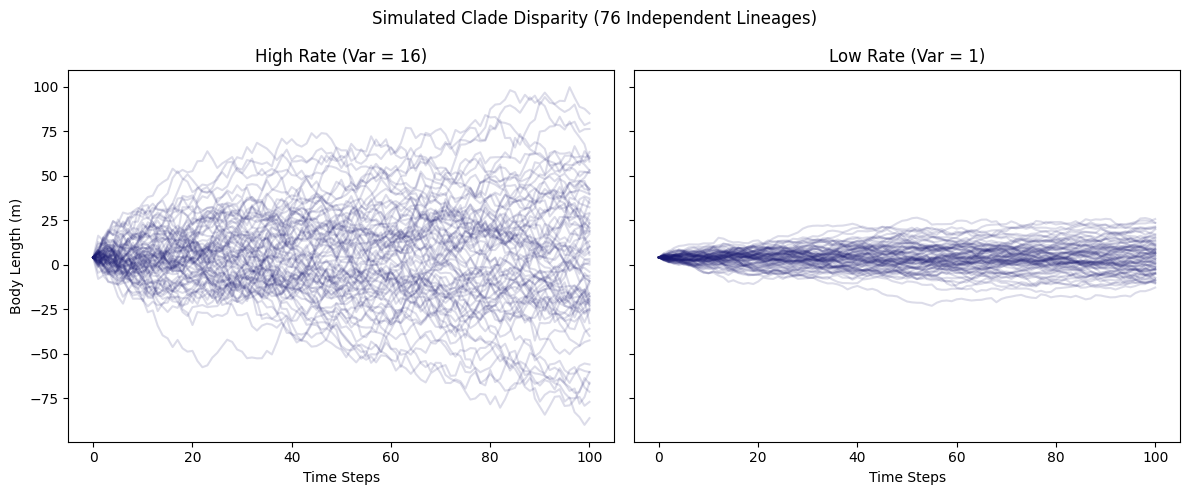

In [3]:
rng = np.random.default_rng(456)

n_species = 76
n_steps = 100
ancestral_size = 4.0

def sim_clade(sd_val, rng):
    sims = np.zeros((n_steps + 1, n_species))
    for i in range(n_species):
        steps = rng.normal(loc=0, scale=sd_val, size=n_steps)
        sims[:, i] = np.cumsum(np.concatenate(([ancestral_size], steps)))
    df = pd.DataFrame(sims, columns=[f"V{i+1}" for i in range(n_species)])
    df["Time"] = np.arange(n_steps + 1)
    long_df = df.melt(id_vars="Time", var_name="Lineage", value_name="Trait_Value")
    return long_df

clade_high = sim_clade(sd_val=4, rng=rng)
clade_high["Regime"] = "High Rate (Var = 16)"

clade_low = sim_clade(sd_val=1, rng=rng)
clade_low["Regime"] = "Low Rate (Var = 1)"

clade_combined = pd.concat([clade_high, clade_low], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, (regime, group) in zip(axes, clade_combined.groupby("Regime", sort=False)):
    for _, sub in group.groupby("Lineage"):
        ax.plot(sub["Time"], sub["Trait_Value"], color="midnightblue", alpha=0.15)
    ax.set_title(regime)
    ax.set_xlabel("Time Steps")

axes[0].set_ylabel("Body Length (m)")
fig.suptitle("Simulated Clade Disparity (76 Independent Lineages)")
plt.tight_layout()
plt.show()


## Brownian motion on simulated phylogenetic trees

Evolution occurs along branching phylogenetic trees. Here, a joint
birth-death branching process with Brownian motion trait evolution is
simulated for pan-group (20 Myr) and crown-group (10 Myr) mysticetes, in
place of R's `TreeSim::sim.bd.age()` + `phytools::fastBM()` pipeline. Each
surviving lineage at the end of the simulated time span is treated as a
"tip", analogous to a tip of a simulated phylogenetic tree. We map empirical
data for modern giant genera alongside the simulated trait space to
visualize how their observed body sizes compare with BM simulations.


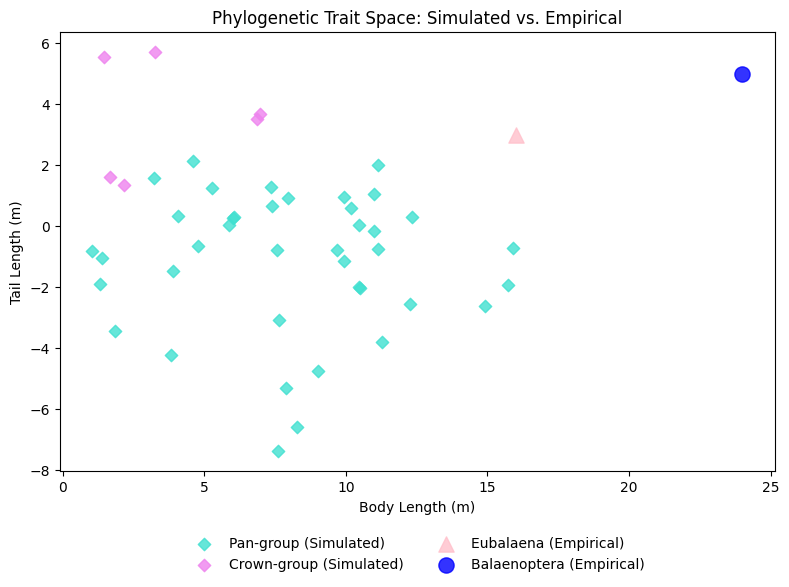

Pan-group simulated tips: 40
Crown-group simulated tips: 6


In [4]:
def simulate_bd_bm(age, lam, mu, sig2_body, sig2_tail, anc_body, anc_tail, rng):
    """Joint birth-death + Brownian motion simulation.

    Grows a population of lineages for `age` time units under a
    constant-rate birth-death process (birth rate `lam`, death rate `mu`).
    Each lineage independently accumulates two Brownian-motion traits
    (body length, tail length) through time. Returns the trait values of
    all lineages alive at t = age (the simulated "tips").
    """
    t = 0.0
    lineages = [{"body": anc_body, "tail": anc_tail}]

    while True:
        n = len(lineages)
        if n == 0:
            return []  # clade went extinct

        rate = n * (lam + mu)
        dt = rng.exponential(1.0 / rate)

        if t + dt >= age:
            dt_final = age - t
            for L in lineages:
                L["body"] += rng.normal(0, np.sqrt(sig2_body * dt_final))
                L["tail"] += rng.normal(0, np.sqrt(sig2_tail * dt_final))
            return lineages

        for L in lineages:
            L["body"] += rng.normal(0, np.sqrt(sig2_body * dt))
            L["tail"] += rng.normal(0, np.sqrt(sig2_tail * dt))
        t += dt

        idx = rng.integers(0, n)
        if rng.random() < lam / (lam + mu):
            lineages.append(dict(lineages[idx]))  # birth: duplicate lineage
        else:
            lineages.pop(idx)  # death


def simulate_until_survives(age, lam, mu, sig2_body, sig2_tail, anc_body, anc_tail, rng):
    """Re-run the simulation if the clade goes extinct, so we always get tips."""
    while True:
        result = simulate_bd_bm(age, lam, mu, sig2_body, sig2_tail, anc_body, anc_tail, rng)
        if result:
            return result


rng = np.random.default_rng(6)

lam, mu = 0.2, 0.05

pan_tips = simulate_until_survives(
    age=20, lam=lam, mu=mu, sig2_body=1.0, sig2_tail=0.5,
    anc_body=4.0, anc_tail=2.0, rng=rng,
)
crown_tips = simulate_until_survives(
    age=10, lam=lam, mu=mu, sig2_body=1.0, sig2_tail=0.5,
    anc_body=4.0, anc_tail=2.0, rng=rng,
)

phylo_data = pd.concat([
    pd.DataFrame(pan_tips).assign(Group="Pan-group (Simulated)"),
    pd.DataFrame(crown_tips).assign(Group="Crown-group (Simulated)"),
], ignore_index=True).rename(columns={"body": "Body_Length", "tail": "Tail_Length"})

# Empirical body and tail length values based on Slater et al. (2017).
empirical_data = pd.DataFrame({
    "Group": ["Eubalaena (Empirical)", "Balaenoptera (Empirical)"],
    "Body_Length": [16, 24],
    "Tail_Length": [3, 5],
})

all_traits = pd.concat([phylo_data, empirical_data], ignore_index=True)

group_style = {
    "Pan-group (Simulated)":      dict(color="turquoise", marker="D", s=40),
    "Crown-group (Simulated)":    dict(color="violet",    marker="D", s=40),
    "Eubalaena (Empirical)":      dict(color="pink",       marker="^", s=120),
    "Balaenoptera (Empirical)":   dict(color="blue",       marker="o", s=120),
}

fig, ax = plt.subplots(figsize=(8, 6))
for group, sub in all_traits.groupby("Group", sort=False):
    style = group_style[group]
    ax.scatter(sub["Body_Length"], sub["Tail_Length"], alpha=0.8, label=group, **style)

ax.set_xlabel("Body Length (m)")
ax.set_ylabel("Tail Length (m)")
ax.set_title("Phylogenetic Trait Space: Simulated vs. Empirical")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2, frameon=False)
plt.tight_layout()
plt.show()

print(f"Pan-group simulated tips: {len(pan_tips)}")
print(f"Crown-group simulated tips: {len(crown_tips)}")


## Ornstein-Uhlenbeck models: strong vs. weak selection

Below, 50 independent lineages are simulated evolving toward an adaptive
optimum of 10 over 25 time steps, contrasting strong vs. weak selective pull
using discrete-time Ornstein-Uhlenbeck (OU) updates:

`x[t+1] = x[t] + alpha * (theta - x[t]) + N(0, sig2)`

All lineages start at an ancestral value of 0 (R's `diverge::random_walks`
default starting point is not shown in the original chunk, so 0 is assumed
here; adjust `x0` below if a different starting value was intended).


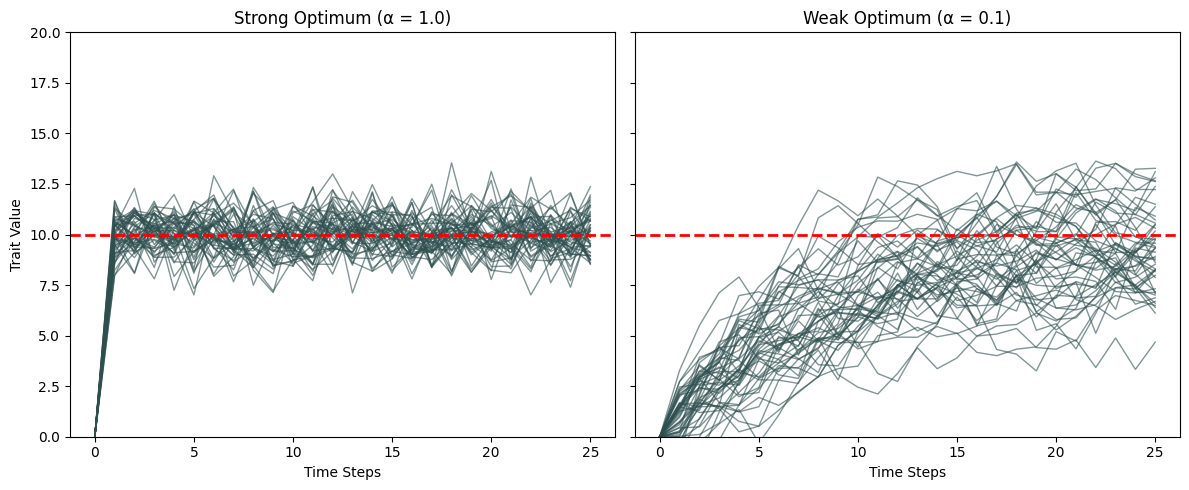

In [5]:
def simulate_ou(n_sims, n_steps, alpha, theta, sig2, x0, rng):
    paths = np.zeros((n_steps + 1, n_sims))
    paths[0, :] = x0
    for t in range(1, n_steps + 1):
        prev = paths[t - 1, :]
        paths[t, :] = prev + alpha * (theta - prev) + rng.normal(0, np.sqrt(sig2), n_sims)
    return paths


rng = np.random.default_rng(999)

N = 50
steps = 25
theta = 10.0
sig2 = 1.0
x0 = 0.0

rw_ou_strong = simulate_ou(N, steps, alpha=1.0, theta=theta, sig2=sig2, x0=x0, rng=rng)
rw_ou_weak = simulate_ou(N, steps, alpha=0.1, theta=theta, sig2=sig2, x0=x0, rng=rng)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

axes[0].plot(rw_ou_strong, color="darkslategrey", alpha=0.6, linewidth=1)
axes[0].axhline(theta, color="red", linestyle="--", linewidth=2)
axes[0].set_xlabel("Time Steps")
axes[0].set_ylabel("Trait Value")
axes[0].set_title("Strong Optimum (\u03b1 = 1.0)")
axes[0].set_ylim(0, 20)

axes[1].plot(rw_ou_weak, color="darkslategrey", alpha=0.6, linewidth=1)
axes[1].axhline(theta, color="red", linestyle="--", linewidth=2)
axes[1].set_xlabel("Time Steps")
axes[1].set_title("Weak Optimum (\u03b1 = 0.1)")
axes[1].set_ylim(0, 20)

plt.tight_layout()
plt.show()


## References

Slater, G. J., Goldbogen, J. A., & Pyenson, N. D. (2017). Independent
evolution of baleen whale gigantism linked to Plio-Pleistocene ocean
dynamics. *Proceedings of the Royal Society B: Biological Sciences,
284*(1855), 20170546. https://doi.org/10.1098/rspb.2017.0546
